In this exercise, you are going to perform simple fine tuning, teaching a pretrained version of resnet18 to tell ants from bees.

In [1]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.9.0+cu126
Torchvision Version:  0.24.0+cu126


In [2]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip hymenoptera_data



--2026-10-09 13:06:02--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 3.173.161.109, 3.173.161.118, 3.173.161.80, ...
Connecting to download.pytorch.org (download.pytorch.org)|3.173.161.109|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M  5.98MB/s    in 10s     

2026-10-09 13:06:12 (4.49 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]

Archive:  hymenoptera_data.zip
   creating: hymenoptera_data/
   creating: hymenoptera_data/train/
   creating: hymenoptera_data/train/ants/
  inflating: hymenoptera_data/train/ants/0013035.jpg  
  inflating: hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg  
  inflating: hymenoptera_data/train/ants/1095476100_3906d8afde.jpg  
  inflating: hymenoptera_data/train/ants/1099452230_d1949d3250.jpg  
  inflating: hymenoptera_data

In [3]:
data_dir = "./hymenoptera_data"

num_classes = 2
batch_size = 8
num_epochs = 15


In [4]:
# Data augmentation and normalization for training
# Just normalization for validation

input_size = 224 #this value matches resnet18


data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(input_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create training and validation datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
# Create training and validation dataloaders
dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2) for x in ['train', 'val']}

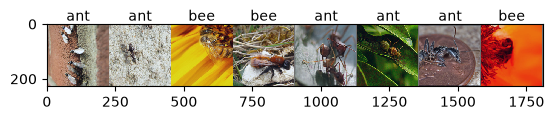

In [5]:
#Let's print some examples:

it = iter(dataloaders_dict['train'])
images,labels = next(it)

grid=torchvision.utils.make_grid(images)

import matplotlib.pyplot as plt

def show(imgGrid,labels,types):
    nImg=len(labels)
    npimg = imgGrid.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), interpolation='nearest')

    plotx=np.linspace(0,npimg.shape[2],nImg+1)
    plotx=np.diff(plotx)/2+plotx[:len(plotx)-1]
    [plt.text(plotx[i],0,types[labels.numpy()[i]],ha='center',va='bottom') for i in range(nImg)]


gridMin=np.min(grid.numpy())
gridMax=np.max(grid.numpy())
show((grid-gridMin)/(gridMax-gridMin),labels,('ant','bee'))



The next cell is  the only one not filled in already.

Experiment with a few different setups:

- try loading with 'pretrained=False', and see what performance you can get.
- try changing to 'pretrained=True', and see  the difference.
- try freezing and unfreezing different layers and see what it does to your accuracy

You can get the names of different layers by just printing the model.


In [10]:
#load model and set up for fine tuning:
model_ft = models.resnet18(pretrained=True) #having False does random initialisation, slow convergence,lower intial accuracy. True uses ImageNet weights, faster convergence, better baseline accuracy. For this example, we will use True.

# optionally freeze parameters

#this will freeze the conv layers, and train only the classifier. Will be fast and use less memory.
for param in list(model_ft.parameters())[:-4]:  # Keep only last block + fc trainable
    param.requires_grad = False
    
# overwrite the 'fc' layer
num_ftrs = model_ft.fc.in_features  # Get the original fc layer input size (usually 512 for ResNet18)
model_ft.fc = nn.Linear(num_ftrs, num_classes)  # Replace with our custom layer (2 classes)

# Detect if we have a GPU available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Send the model to GPU
model_ft = model_ft.to(device)

# find parameters to update
params_to_update = []
#(loop over "name,param in model_ft.named_parameters()" and append to params_to_update if requires_grad==True)
for name, param in model_ft.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print(f"Trainable parameter: {name}")
    else:
        print(f"Frozen parameter: {name}")
# Set up optimizer for non-frozen parameters
optimizer_ft = torch.optim.SGD(params_to_update, lr=0.001, momentum=0.9)

/home/stefan_stringer/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/stefan_stringer/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/stefan_stringer/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.10MB/s]


Using device: cuda:0
Frozen parameter: conv1.weight
Frozen parameter: bn1.weight
Frozen parameter: bn1.bias
Frozen parameter: layer1.0.conv1.weight
Frozen parameter: layer1.0.bn1.weight
Frozen parameter: layer1.0.bn1.bias
Frozen parameter: layer1.0.conv2.weight
Frozen parameter: layer1.0.bn2.weight
Frozen parameter: layer1.0.bn2.bias
Frozen parameter: layer1.1.conv1.weight
Frozen parameter: layer1.1.bn1.weight
Frozen parameter: layer1.1.bn1.bias
Frozen parameter: layer1.1.conv2.weight
Frozen parameter: layer1.1.bn2.weight
Frozen parameter: layer1.1.bn2.bias
Frozen parameter: layer2.0.conv1.weight
Frozen parameter: layer2.0.bn1.weight
Frozen parameter: layer2.0.bn1.bias
Frozen parameter: layer2.0.conv2.weight
Frozen parameter: layer2.0.bn2.weight
Frozen parameter: layer2.0.bn2.bias
Frozen parameter: layer2.0.downsample.0.weight
Frozen parameter: layer2.0.downsample.1.weight
Frozen parameter: layer2.0.downsample.1.bias
Frozen parameter: layer2.1.conv1.weight
Frozen parameter: layer2.1.bn

In [11]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    since = time.time()

    val_acc_history = []
    train_acc_history=[]

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    #evaluate before training:
    model.eval()   # Set model to evaluate mode

    running_corrects = 0
    for inputs, labels in dataloaders['train']:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(dataloaders['train'].dataset)
    train_acc_history.append(acc)
    print('train acc:',acc)

    running_corrects = 0
    for inputs, labels in dataloaders['val']:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      running_corrects += torch.sum(preds == labels.data)

    acc = running_corrects.double() / len(dataloaders['val'].dataset)
    val_acc_history.append(acc)
    print('val acc:',acc)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'val':
                val_acc_history.append(epoch_acc)
            if phase == 'train':
                train_acc_history.append(epoch_acc)

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history

In [12]:
# Setup the loss fxn
criterion = nn.CrossEntropyLoss()

# Train and evaluate
model_ft, hist_val, hist_train = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=num_epochs)

train acc: tensor(0.4672, device='cuda:0', dtype=torch.float64)
val acc: tensor(0.5033, device='cuda:0', dtype=torch.float64)
Epoch 0/14
----------
train Loss: 0.5753 Acc: 0.7008
val Loss: 0.2789 Acc: 0.9346

Epoch 1/14
----------
train Loss: 0.3316 Acc: 0.8648
val Loss: 0.2162 Acc: 0.9020

Epoch 2/14
----------
train Loss: 0.3156 Acc: 0.8607
val Loss: 0.1908 Acc: 0.9412

Epoch 3/14
----------
train Loss: 0.3253 Acc: 0.8566
val Loss: 0.1944 Acc: 0.9281

Epoch 4/14
----------
train Loss: 0.4759 Acc: 0.7869
val Loss: 0.1864 Acc: 0.9346

Epoch 5/14
----------
train Loss: 0.2855 Acc: 0.8730
val Loss: 0.2072 Acc: 0.9216

Epoch 6/14
----------
train Loss: 0.3204 Acc: 0.8525
val Loss: 0.2044 Acc: 0.9150

Epoch 7/14
----------
train Loss: 0.2550 Acc: 0.8934
val Loss: 0.1923 Acc: 0.9281

Epoch 8/14
----------
train Loss: 0.2429 Acc: 0.8852
val Loss: 0.2961 Acc: 0.8889

Epoch 9/14
----------
train Loss: 0.2152 Acc: 0.9344
val Loss: 0.1855 Acc: 0.9281

Epoch 10/14
----------
train Loss: 0.1835 Ac

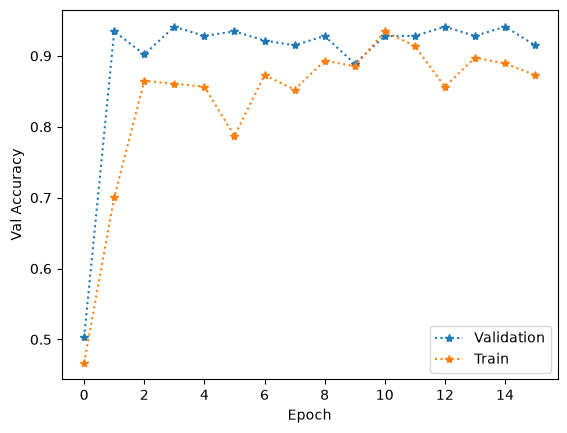

In [13]:
import matplotlib.pyplot as plt

accs=[x.cpu().numpy() for x in hist_val]
accs=np.array(accs)
plt.plot(accs,':*')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')

accs=[x.cpu().numpy() for x in hist_train]
accs=np.array(accs)
plt.plot(accs,':*')

plt.legend(['Validation','Train'])

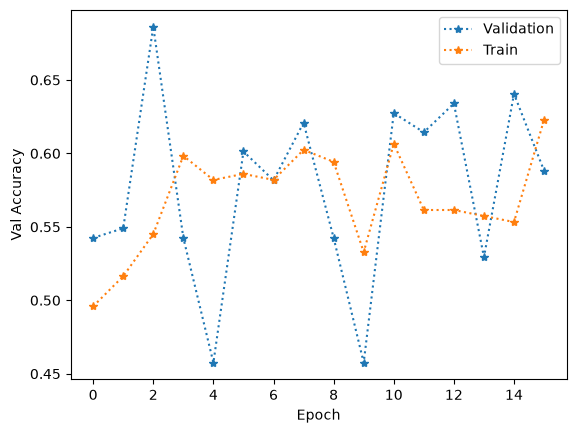

In [9]:
import matplotlib.pyplot as plt

accs=[x.cpu().numpy() for x in hist_val]
accs=np.array(accs)
plt.plot(accs,':*')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')

accs=[x.cpu().numpy() for x in hist_train]
accs=np.array(accs)
plt.plot(accs,':*')

plt.legend(['Validation','Train'])
